## House grouping system

In [96]:
import pandas as pd
import seaborn as sns  
import sympy as sp  
import xgboost as xgb  
import matplotlib.pyplot as plt  
import numpy as np  
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score
from sklearn.tree import DecisionTreeClassifier

In [74]:
df = pd.read_csv('/workspaces/K-means-VicentePolo/data/raw/housing.csv') 

In [75]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [76]:
df= df.drop(columns=['HouseAge','AveRooms','AveBedrms','Population','AveOccup','MedHouseVal'])

In [77]:
df.head()

,MedInc,Latitude,Longitude
0,8.3252,37.88,-122.23
1,8.3014,37.86,-122.22
2,7.2574,37.85,-122.24
3,5.6431,37.85,-122.25
4,3.8462,37.85,-122.25


Revisamos que no haya valores duplicados

In [78]:
df.duplicated().value_counts()


False    20635
True         5
Name: count, dtype: int64

In [79]:
df = df.drop_duplicates()

In [80]:
df.duplicated().value_counts()

False    20635
Name: count, dtype: int64

Repartimos 80/20 entre train y test

In [81]:
X_train, X_test = train_test_split(df, test_size = 0.2, random_state = 42)

Construccion del modelo 

In [82]:
from sklearn.cluster import KMeans

km_model = KMeans(n_clusters = 6,random_state = 42)
km_model.fit(X_train)

KMeans(n_clusters=6, random_state=42)

Asignacion de clusters

In [83]:
X_train['cluster'] = km_model.labels_
y_train = list(km_model.labels_)

Comprobamos si tal y como indican en las instrucciones, debemos de alguna manera trabajar con la columna clusters si se ha quedado en objeto, y vemos que no es así.

In [58]:
X_train.dtypes

MedInc       float64
Latitude     float64
Longitude    float64
cluster        int32
dtype: object

Antes de plotear resultados, podemos cuestionarnos por qué en el ejercicio se nos indica que asignemos 6 clusters y si es de verdad eficiente: 

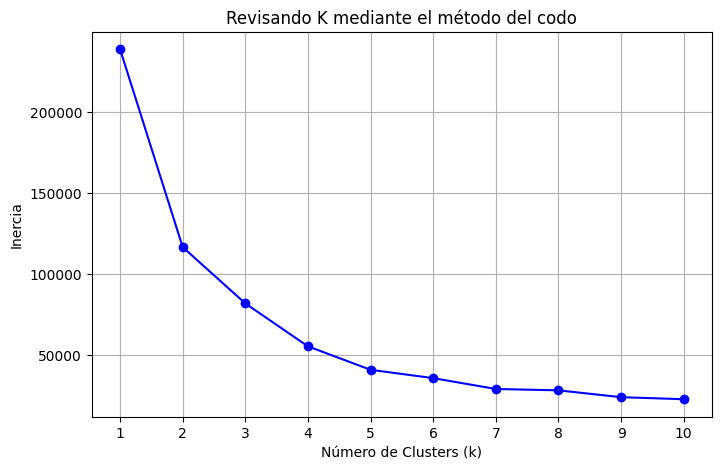

In [84]:
inertia = []
K_range = range(1, 11)  # Desde 1 hasta 10 clusters

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_train)
    inertia.append(kmeans.inertia_)

# Graficar el método del codo
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o', linestyle='-', color='b')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Inercia')
plt.title('Revisando K mediante el método del codo')
plt.xticks(K_range)
plt.grid(True)
plt.show()

Mirando los resultados, quizá 7 u 8 clusters sería una opción mas adecuada, dado que es cuando la linea parece aplanarse mas y no tiene un descenso acusado. 

## Plotear resultados

### Para que tenga una mayor visibilidad he optado por hacer tres gráficos: 
1- Que muestra solo los puntos de valor

2- Que muestra los centroides

3- Muestra los puntos de valor con poca opacidad y los centroides

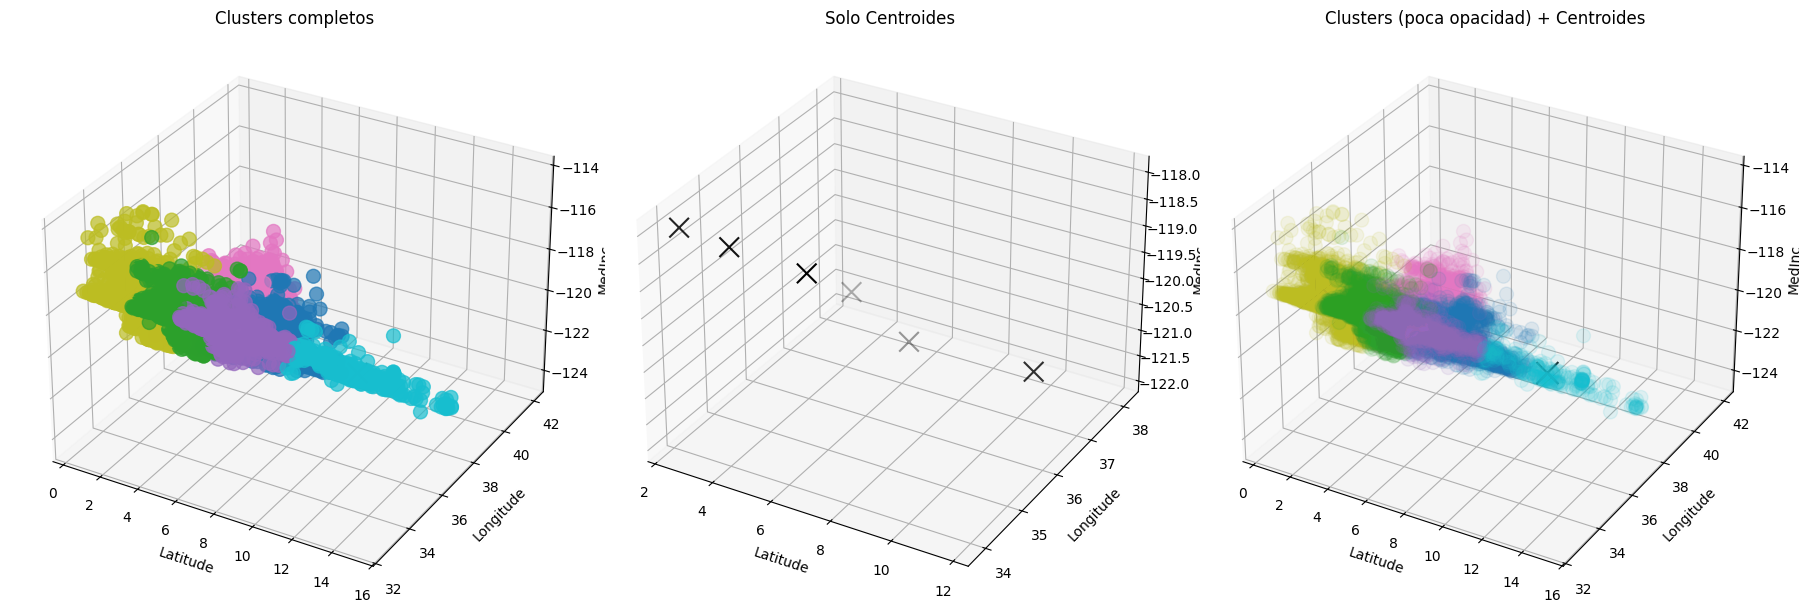

In [60]:
centroids=km_model.cluster_centers_

fig = plt.figure(figsize=(18, 6))

ax1 = fig.add_subplot(131, projection='3d')
ax1.scatter(
    X_train.iloc[:, 0], X_train.iloc[:, 1], X_train.iloc[:, 2],
    c=X_train['cluster'], cmap='tab10', s=100, alpha=0.7
)
ax1.scatter(
    centroids[:, 0], centroids[:, 1], centroids[:, 2],
    s=200, c='black', marker='x', label='Centroides'
)
ax1.set_title('Clusters completos')
ax1.set_xlabel('Latitude')
ax1.set_ylabel('Longitude')
ax1.set_zlabel('MedInc')


ax2 = fig.add_subplot(132, projection='3d')
ax2.scatter(
    centroids[:, 0], centroids[:, 1], centroids[:, 2],
    s=200, c='black', marker='x', label='Centroides'
)
ax2.set_title('Solo Centroides')
ax2.set_xlabel('Latitude')
ax2.set_ylabel('Longitude')
ax2.set_zlabel('MedInc')


ax3 = fig.add_subplot(133, projection='3d')
ax3.scatter(
    X_train.iloc[:, 0], X_train.iloc[:, 1], X_train.iloc[:, 2],
    c=X_train['cluster'], cmap='tab10', s=100, alpha=0.1  
)
ax3.scatter(
    centroids[:, 0], centroids[:, 1], centroids[:, 2],
    s=250, c='black', marker='x', label='Centroides'
)
ax3.set_title('Clusters (poca opacidad) + Centroides')
ax3.set_xlabel('Latitude')
ax3.set_ylabel('Longitude')
ax3.set_zlabel('MedInc')

plt.tight_layout()
plt.show()


Entiendo que, los valores están bien distribuidos sin grandes estridencias o valores anormales. 

(He visto que Jose María utilizaba una herramienta 3d y he querido probar)

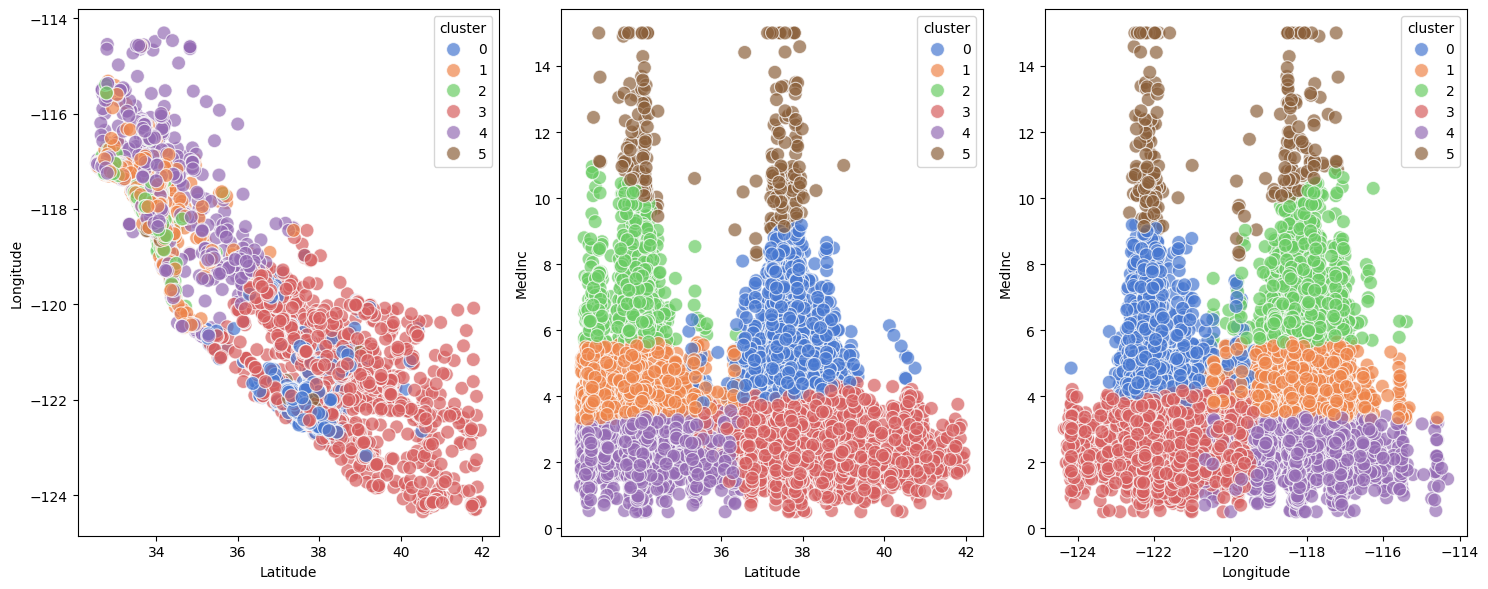

In [61]:
fig, axis = plt.subplots(1,3, figsize = (15, 6))

sns.scatterplot(ax = axis[0], data = X_train, x = "Latitude", y = "Longitude", hue = "cluster", palette = "muted",s =100, alpha=0.7)
sns.scatterplot(ax = axis[1], data = X_train, x = "Latitude", y = "MedInc", hue = "cluster", palette = "muted",s =100, alpha=0.7)
sns.scatterplot(ax = axis[2], data = X_train, x = "Longitude", y = "MedInc", hue = "cluster", palette = "muted",s =100, alpha=0.7)
plt.tight_layout()

plt.show()

Se puede ver en el gráfico como los puntos de colores se agrupan de una manera uniforme, incluso en puntos de coincidencia (por así decirlo).

Cuando tratamos longitud y latitud hay puntos que amontonan, quizá un mayor número de cluster ayudaría a rebajar la varianza y así darle un poco mas de coherencia. 

En lo que refiere a latitud o longitud por separado con MedInc, todo tiene un mayor sentido. 

## Predicciones con el test set

In [107]:
y_test = list(km_model.predict(X_test))
X_test["cluster"] = y_test
X_test.head()

,MedInc,Latitude,Longitude,cluster
8572,8.4680,33.90,-118.41,2
1712,3.9722,37.97,-122.32,3
15916,3.4583,37.74,-122.42,3
5196,1.6625,33.94,-118.27,4
13583,1.5156,34.13,-117.29,4


In [93]:
silhouette_avg = silhouette_score(X_test, y_test)
print(f'Silhouette Score: {silhouette_avg:.2f}')
db_index = davies_bouldin_score(X_test, y_test)
print(f'Davies-Bouldin Index: {db_index:.2f}')


Silhouette Score: 0.55
Davies-Bouldin Index: 0.68


Las métricas de Silhouette y DB son bastante buenas

Seleccionamos RandomTree

In [97]:
km_model = DecisionTreeClassifier(random_state = 42)
km_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

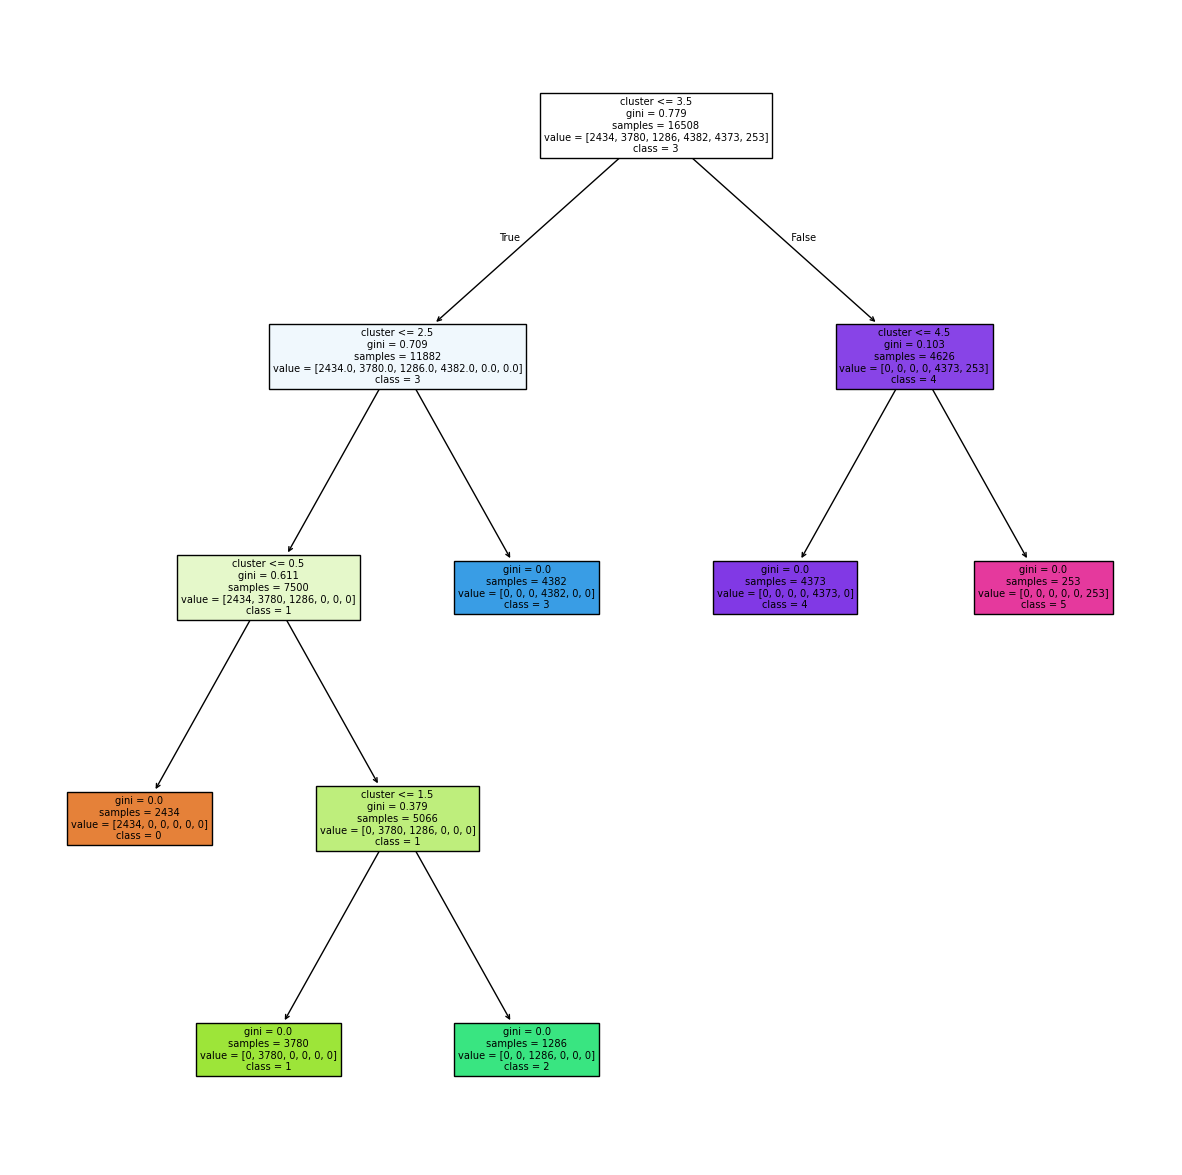

In [100]:
from sklearn import tree

fig = plt.figure(figsize=(15,15))

tree.plot_tree(km_model, feature_names = list(X_train.columns), class_names = ["0", "1", "2", "3", "4", "5"], filled = True)

plt.show()

In [109]:
y_pred = km_model.predict(X_test)

acc= accuracy_score(y_test, y_pred)
print("La accuracy que se muestra es de", acc*100, "%")

La accuracy que se muestra es de 100.0 %
